In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ielādē 1. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week1/shoppers_clean.csv')

print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


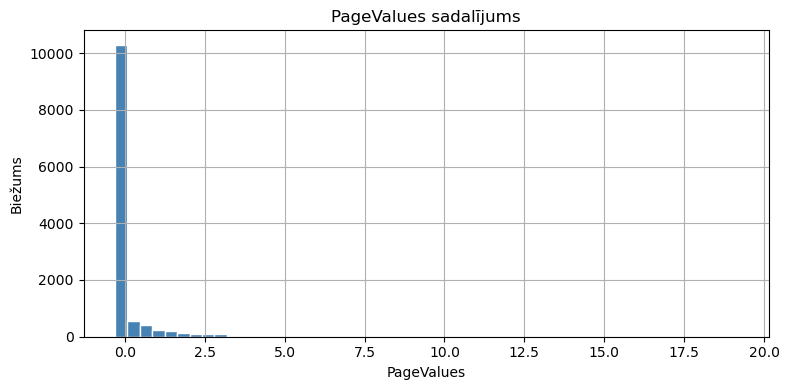

In [3]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))

df['PageValues'].hist(
    bins=50,
    color='steelblue',
    edgecolor='white'
)

plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')

plt.tight_layout()
plt.show()

In [4]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

Features skaits: 26
Target: PageValues


Kolonna Revenue tika izņemta no features, lai novērstu data leakage.
Data leakage notiek tad, kad modelis treniņa laikā saņem informāciju,
kas reālajā prognozēšanas brīdī nebūtu pieejama.
Tas padara modeli nederīgu darbam ar jauniem datiem.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


In [6]:
# Modeļa trenēšana
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineāra regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


# Lineārās regresijas metriku interpretācija

## MAE
MAE parāda vidējo absolūto kļūdu starp īstajām un prognozētajām vērtībām.
Jo mazāks MAE, jo precīzāks modelis.

## RMSE
RMSE arī mēra kļūdu lielumu. Tas palīdz pamanīt gadījumus, kur modelis kļūdās ļoti stipri. 
Jo mazāks RMSE, jo labāk modelis darbojas.

## R²
R² parāda, cik lielu daļu no datu variācijas modelis spēj izskaidrot.
Vērtība tuvāk 1 nozīmē labāku modeli. Ja R² ir zems, tad modelis slikti prognozē target mainīgo.

---
Modelis ir pietiekami labs, ja: MAE un RMSE ir salīdzinoši mazi, bet R² ir pietiekami augsts. Savukārt, ja R² ir zems un kļūdas ir lielas,
tad modelis nav īpaši precīzs.

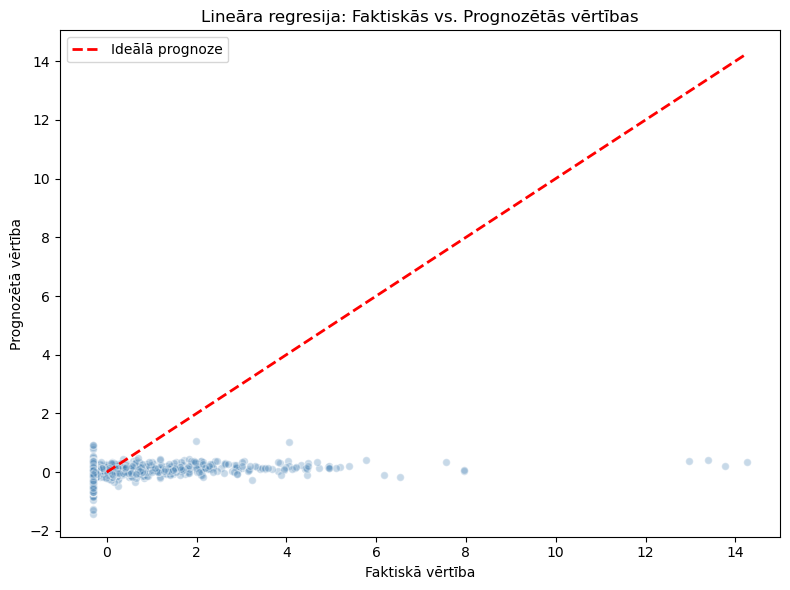

In [7]:
#3.1. Faktiskās vs. prognozētās vērtības
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

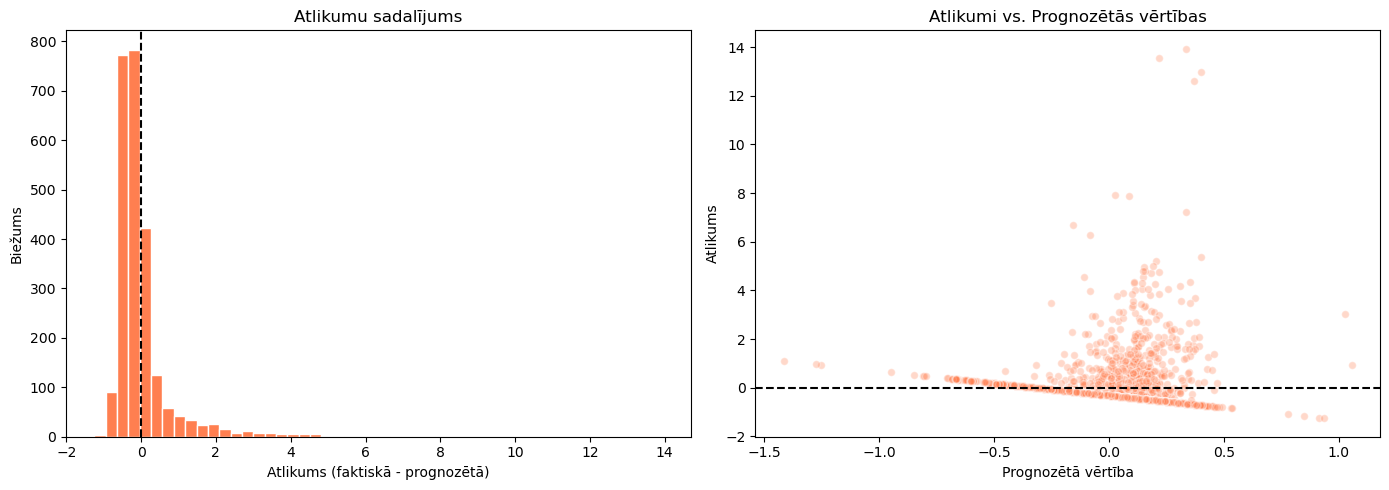

In [8]:
#3.2. Atlikumu (residuals) analīze
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

1. Faktiskās vs. Prognozētās vērtības (Scatter grafiks)
•	Manā grafikā punkti ir ļoti tālu no sarkanās svītras. Ideālā gadījumā visiem zilajiem punktiem vajadzētu atrasties uz vai ļoti tuvu sarkanajai pārtrauktajai līnijai ("Ideālā prognoze").
•	Ko tas nozīmē par modeļa precizitāti? Modelis strādā izteikti neprecīzi. Kamēr faktiskās vērtības pieaug līdz pat 14, modeļa prognozes gandrīz visiem punktiem "iestrēgst" un "guļ" horizontāli gandrīz uz nulles (robežās no -1 līdz 1). Modelis nespēj uztvert vērtību pieaugumu un visam prognozē aptuveni vienu un to pašu vidējo vērtību.

2. Atlikumu analīze (Residuals)
•	Atlikumu sadalījums (Histogramma): Atlikumi (kļūdas) nav sadalīti simetriski ap nulli. Histogrammai ir izteikta "ilgā aste" uz labo pusi (pozitīvo vērtību virzienā). Tas nozīmē, ka modelis bieži un stipri neprognozē pietiekami lielas vērtības.
•	Atlikumi vs. Prognozētās vērtības: Šajā grafikā punkti nav izkliedēti vienmērīgi ap nulles līniju. Ir redzams, ka prognozētajai vērtībai pieaugot, kļūdas kļūst arvien milzīgākas.
•	Vai ir kāds bias (novirze)? Jā, ir izteikts sistemātisks bias. Modelis smagi tiecas pazemināt prognozes lielākām faktiskajām vērtībām, radot lielas, pozitīvas kļūdas.

Kopsavilkums par modeļa kvalitāti
Vizualizācijas skaidri parāda, ka modeļa kvalitāte ir neapmierinoša. Datu struktūra nav lineāra, vai arī modelim kritiski trūkst citu svarīgu pazīmju (features), kas palīdzētu izskaidrot lielās vērtības. Lineārā regresija šajā gadījumā nespēj uztvert reālo sakarību datos.

In [9]:
# 4.1. PolynomialFeatures ar degree=2

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveido pipeline: PolynomialFeatures → LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364


In [10]:
comparison_df = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Polinomiālā regresija'],
    'MAE': [mae, mae_poly],
    'RMSE': [rmse, rmse_poly],
    'R²': [r2, r2_poly]
})

print(comparison_df)

                 Modelis       MAE      RMSE        R²
0      Lineārā regresija  0.500925  0.994572  0.045556
1  Polinomiālā regresija  0.488841  0.999347  0.036370


In [11]:
# 4.3. Pārbaudīt overfit

# Lineārā regresija
r2_train_lr = lr_model.score(X_train, y_train)
r2_test_lr = lr_model.score(X_test, y_test)

# Polinomiālā regresija
r2_train_poly = poly_pipeline.score(X_train, y_train)
r2_test_poly = poly_pipeline.score(X_test, y_test)

print("=== R² salīdzinājums ===")

print(f"Lineārā regresija TRAIN R²: {r2_train_lr:.4f}")
print(f"Lineārā regresija TEST  R²: {r2_test_lr:.4f}")

print()

print(f"Polinomiālā regresija TRAIN R²: {r2_train_poly:.4f}")
print(f"Polinomiālā regresija TEST  R²: {r2_test_poly:.4f}")

# Pārbauda overfitting

if abs(r2_train_lr - r2_test_lr) > 0.10:
    print("BRĪDINĀJUMS: Lineārajai regresijai iespējams overfitting!")

if abs(r2_train_poly - r2_test_poly) > 0.10:
    print("BRĪDINĀJUMS: Polinomiālajai regresijai iespējams overfitting!")

=== R² salīdzinājums ===
Lineārā regresija TRAIN R²: 0.0568
Lineārā regresija TEST  R²: 0.0456

Polinomiālā regresija TRAIN R²: 0.1334
Polinomiālā regresija TEST  R²: 0.0364


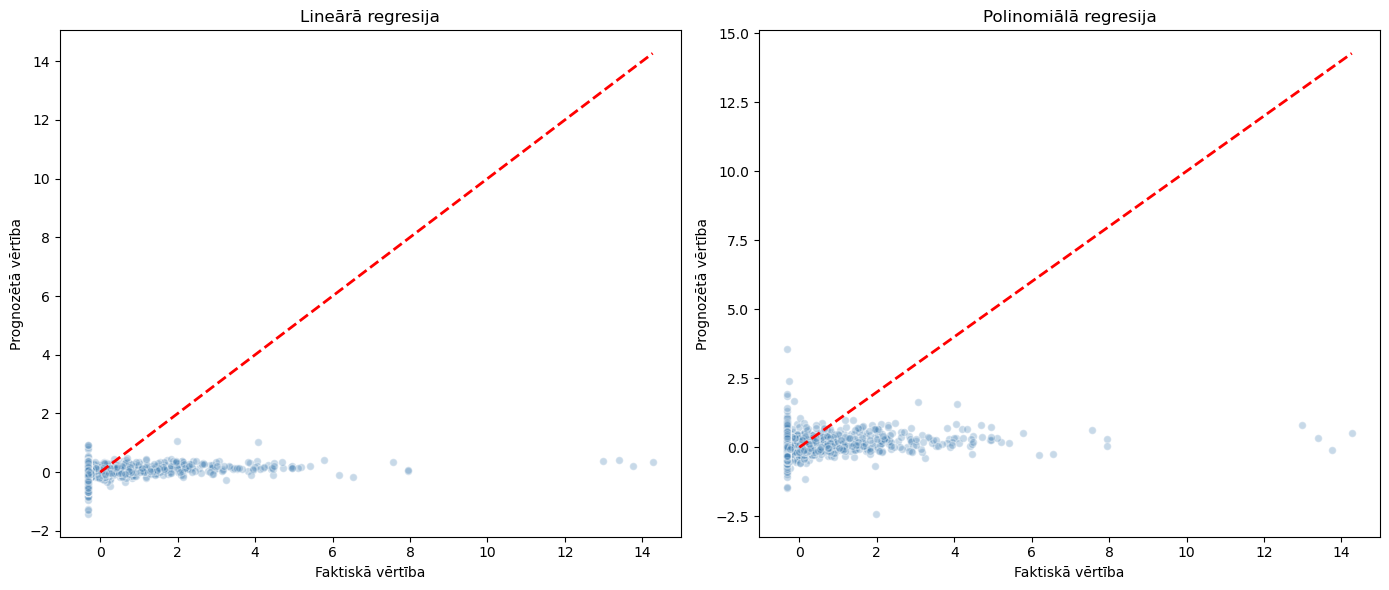

In [12]:
# 4.4. Vizuāls salīdzinājums

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [
    ('Lineārā regresija', y_pred),
    ('Polinomiālā regresija', y_pred_poly)
]

for ax, (title, preds) in zip(axes, models):

    ax.scatter(
        y_test,
        preds,
        alpha=0.3,
        color='steelblue',
        edgecolors='white',
        s=30
    )

    # Ideālā līnija
    max_val = max(y_test.max(), preds.max())

    ax.plot(
        [0, max_val],
        [0, max_val],
        'r--',
        linewidth=2
    )

    ax.set_title(title)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')

plt.tight_layout()
plt.show()

SECINĀJUMI:
Salīdzinot testēšanas rezultātus, Lineārās regresijas modelis labāk prognozē PageValues, jo tam ir augstāks determinācijas koeficients (R2 = 0.045556 pret Polinomiālā modeļa 0.036370) un mazāka RMSE kļūda (0.994572 pret 0.999347). 

Lai gan polinomiālajam modelim ir nedaudz zemāka vidējā absolūtā kļūda (MAE), tas kopumā nav sniedzis nekādu vērā ņemamu uzlabojumu un R2 vērtība testā pat ir pazeminājusies.

Datos ir saskatāmas skaidras overfitting pazīmes polinomiālajam modelim, jo tā TRAIN R2 (0.1334) ir ievērojami augstāks nekā TEST R2 (0.0364), kas liecina, ka modelis nespēj vispārināt jaunu informāciju. 

Uzņēmumam nerekomendētu izmantot nevienu no šiem diviem modeļiem praktiskām prognozēm, jo abi uzrāda kritiski zemu precizitāti. Tomēr, ja būtu jāizvēlas starp abiem, lineārais modelis ir labāka un drošāka izvēle, jo tas ir stabilāks, skaitļošanas ziņā vienkāršāks.